# NBA Market Edge: Exploratory Data Analysis

**Goal of the project:** estimate calibrated win probabilities for NBA games and, in later phases,
compare them with Kalshi prediction-market prices.

**Goal of this notebook:** understand the historical data before modeling. What does it contain,
how clean is it, and which pre-game information is related to who wins?

**Data:** 7,230 regular-season games, 2020-21 through 2025-26, from the NBA stats API (`nba_api`, `LeagueGameLog`).
All processing lives in `src/`. This notebook only loads the outputs and analyzes them.

| File | Built by | One row = |
|---|---|---|
| `data/processed/nba_games.csv` | `src/clean_data.py` | one game (includes 2018-20 Elo warm-up seasons) |
| `data/processed/nba_features.csv` | `src/feature_engineering.py` | one game, with pre-game features only |

**Contents**
1. Dataset overview
2. Data quality
3. Home-court advantage
4. Scoring and point differentials
5. Recent form vs. outcomes
6. Rest and back-to-backs
7. Elo ratings and calibration
8. Feature signal summary
9. Key findings and next steps

> Throughout, relationships are **correlations**. They show which pre-game information is useful for
> *prediction*, not what *causes* teams to win.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.clean_data import load_all_raw_seasons, load_games_table, raw_data_quality_report
from src.collect_data import SEASONS
from src.feature_engineering import FEATURES_PATH

# Chart style: one consistent, colorblind-validated palette and quiet axes.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e6e5e0"
sns.set_theme(style="whitegrid", rc={
    "axes.edgecolor": GRID, "grid.color": GRID, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.spines.top": False, "axes.spines.right": False, "figure.dpi": 110,
})
pd.set_option("display.max_columns", 40)

all_games = load_games_table()
games = all_games[all_games["season"].isin(SEASONS)].reset_index(drop=True)   # modeling seasons only
features = pd.read_csv(FEATURES_PATH, dtype={"game_id": str}, parse_dates=["game_date"])
true_home = features[features["home_court"] == 1]   # excludes neutral-site games

print(f"games: {len(games):,} | features: {features.shape[0]:,} rows x {features.shape[1]} columns")

games: 7,230 | features: 7,230 rows x 28 columns


## 1. Dataset overview

**Grain:** the raw API returns one row per *team* per game. Cleaning merges each pair into one row per *game*,
with `home_*` and `away_*` columns and the target `home_team_win` (1 = home team won).
This is a **binary classification** problem: there are two possible outcomes and no ties in the NBA.
What we really want from a model is the *probability* of each outcome.

In [2]:
games[["game_id", "game_date", "season", "home_team", "away_team", "home_score", "away_score",
       "home_team_win", "is_neutral_site"]].head()

,game_id,game_date,season,home_team,away_team,home_score,away_score,home_team_win,is_neutral_site
0,0022000001,2020-12-22,2020-21,BKN,GSW,125,99,1,0
1,0022000002,2020-12-22,2020-21,LAL,LAC,109,116,0,0
2,0022000003,2020-12-23,2020-21,BOS,MIL,122,121,1,0
3,0022000004,2020-12-23,2020-21,PHX,DAL,106,102,1,0
4,0022000010,2020-12-23,2020-21,CLE,CHA,121,114,1,0


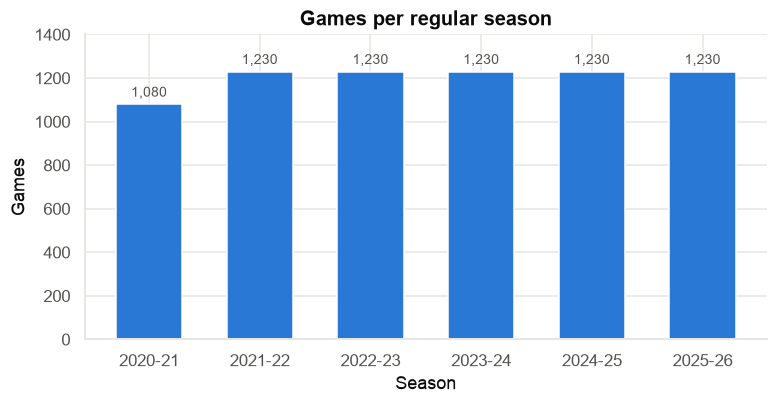

In [3]:
games_per_season = games.groupby("season").size()

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(games_per_season.index, games_per_season.values, color=BLUE, width=0.6)
ax.bar_label(bars, fmt="{:,.0f}", padding=3, color=MUTED, fontsize=9)
ax.set(title="Games per regular season", xlabel="Season", ylabel="Games")
ax.set_ylim(0, 1400)
plt.show()

**X-axis:** season. **Y-axis:** number of regular-season games.

**What it shows:** every season has 1,230 games (30 teams × 82 games ÷ 2), except **2020-21 with 1,080**.
That season was shortened to 72 games and started in December because of COVID.

**Why it matters:** 2020-21 is unusual in other ways too (few or no fans, postponements, the Raptors
playing home games in Tampa). Later we should check whether including it helps or hurts the model.

## 2. Data quality

These checks run automatically in `src/clean_data.py`, and the pipeline stops if any of them fail after cleaning.

In [4]:
report = raw_data_quality_report(load_all_raw_seasons(SEASONS))
pd.Series(report, name="value").to_frame()

,value
team_game_rows,14460
games,7230
exact_duplicate_rows,0
duplicate_game_team_rows,0
games_without_two_rows,0
games_without_two_distinct_teams,0
games_without_exactly_one_winner,0
rows_with_unreadable_matchup,0
games_with_two_home_teams,0
games_with_no_home_team,10


**Findings**

- **No duplicates**, every game has exactly **two distinct teams** and **exactly one winner**.
- **One missing value:** `FT_PCT` for Boston on 2024-04-09. Boston attempted 0 free throws, so FT% = 0/0 is
  undefined. It is left as missing rather than filled with an invented value.
- **10 games with no listed home team.** From 2024-25 onward, the API lists *both* teams with "@" for
  neutral-site games (international games, NBA Cup semifinals in Las Vegas). Before 2024-25, neutral-site
  games show a nominal home team, so 6 such games were identified manually and documented in `src/clean_data.py`.

In [5]:
neutral = games[games["is_neutral_site"] == 1][["game_date", "season", "home_team", "away_team", "home_team_win"]]
print(f"{len(neutral)} neutral-site games in the modeling seasons")
neutral

16 neutral-site games in the modeling seasons


,game_date,season,home_team,away_team,home_team_win
2748,2022-12-17,2022-23,SAS,MIA,0
2987,2023-01-19,2022-23,DET,CHI,0
3658,2023-11-09,2023-24,ORL,ATL,0
3846,2023-12-07,2023-24,MIL,IND,0
3847,2023-12-07,2023-24,LAL,NOP,1
4096,2024-01-11,2023-24,CLE,BKN,1
4856,2024-11-02,2024-25,MIA,WAS,1
5144,2024-12-14,2024-25,ATL,MIL,0
5145,2024-12-14,2024-25,HOU,OKC,0
5415,2025-01-23,2024-25,IND,SAS,0


**Why it matters:** if neutral-site games were treated as normal home games, a model would give a
"home" team home-court advantage it didn't have. The features include `home_court = 0` for these games.

### Missing values in the features

In [6]:
missing = features.isna().sum()
missing[missing > 0].to_frame("missing_games")

,missing_games
home_win_pct_last5,89
home_win_pct_last10,89
home_avg_pts_scored_last10,89
home_avg_pts_allowed_last10,89
home_avg_point_diff_last10,89
home_days_since_last_game,89
away_win_pct_last5,91
away_win_pct_last10,91
away_avg_pts_scored_last10,91
away_avg_pts_allowed_last10,91


Every missing value comes from a **season opener**: a team's first game of a season has no earlier games
to average. Home and away totals add up to 180 = 30 teams × 6 seasons. Rolling stats reset each season
(rosters change), and missing values are **never filled with later information**, which would leak the future.
Elo has no missing values because ratings carry over between seasons.

## 3. Home-court advantage

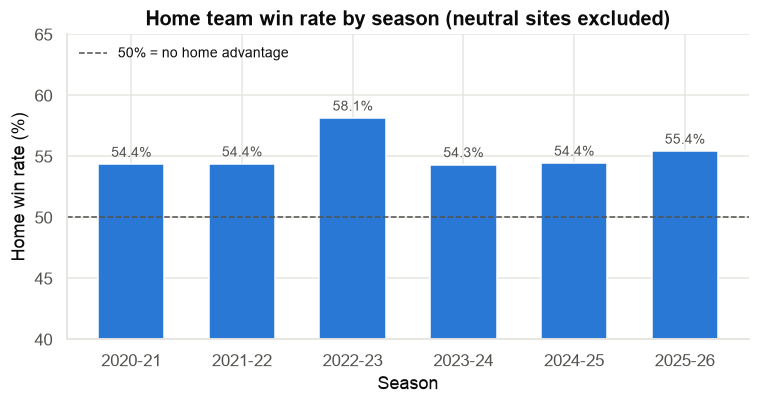

Overall home win rate: 55.2% across 7,214 games


In [7]:
home_rate = true_home.groupby("season")["home_team_win"].mean()
overall = true_home["home_team_win"].mean()

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(home_rate.index, home_rate.values * 100, color=BLUE, width=0.6)
ax.bar_label(bars, labels=[f"{v:.1%}" for v in home_rate.values], padding=3, color=MUTED, fontsize=9)
ax.axhline(50, color=MUTED, linestyle="--", linewidth=1, label="50% = no home advantage")
ax.legend(frameon=False, loc="upper left", fontsize=9)
ax.set(title="Home team win rate by season (neutral sites excluded)", xlabel="Season", ylabel="Home win rate (%)")
ax.set_ylim(40, 65)
plt.show()
print(f"Overall home win rate: {overall:.1%} across {len(true_home):,} games")

**X-axis:** season. **Y-axis:** share of games won by the home team.

**What it shows:** home teams win about **55%** of games, and this is stable across seasons.
2022-23 is the highest season (about 58%).

**Why it matters:**
- **55% is the first baseline to beat.** A "model" that always picks the home team is right 55% of the time.
- **2020-21 isn't lower** even though most games had few or no fans. That suggests crowds may not be the
  main source of home advantage (travel, familiarity and rest are other candidates). This is a correlation
  in one unusual season, not proof.
- Older rating systems assume a home win rate of about 64% between equal teams. Section 7 shows why that matters.

## 4. Scoring and point differentials

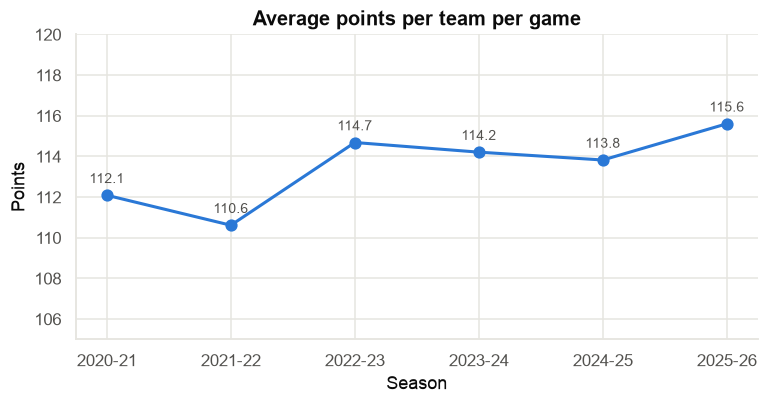

In [8]:
scoring = games.assign(points_per_team=(games["home_score"] + games["away_score"]) / 2)
avg_points = scoring.groupby("season")["points_per_team"].mean()

fig, ax = plt.subplots(figsize=(8, 3.6))
ax.plot(avg_points.index, avg_points.values, color=BLUE, linewidth=2, marker="o", markersize=7)
for season, value in avg_points.items():
    ax.annotate(f"{value:.1f}", (season, value), textcoords="offset points", xytext=(0, 8),
                ha="center", color=MUTED, fontsize=9)
ax.set(title="Average points per team per game", xlabel="Season", ylabel="Points")
ax.set_ylim(105, 120)
plt.show()

**X-axis:** season. **Y-axis:** average points scored by one team in a game.

**What it shows:** scoring dipped in 2021-22 (110.6), jumped in 2022-23 (114.7), and reached 115.6 in 2025-26.
Rule changes and more three-point shooting are commonly cited reasons, but this dataset doesn't test that.

**Why it matters:** "averages 115 points" means something different in 2021 than in 2025. Features that
compare the two teams in the *same* game (home minus away) are not affected by league-wide trends.
Raw point totals compared across seasons are.

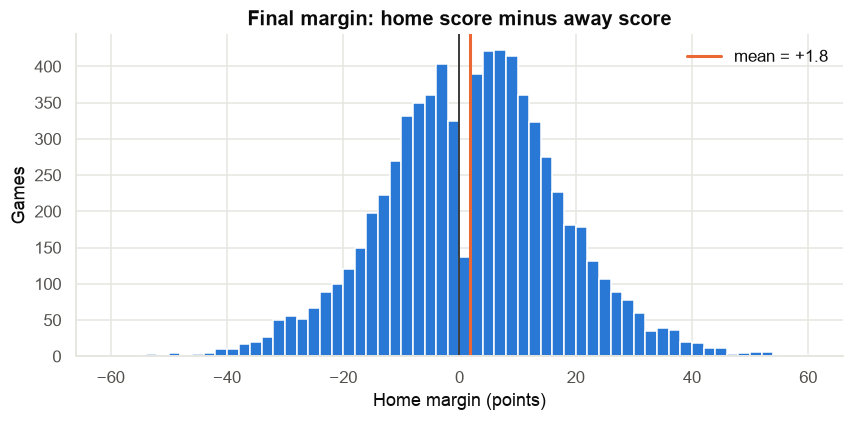

median margin +3 | std 15.4 | decided by 3 or fewer: 14.5% | by 15+: 32.6%


In [9]:
point_diff = games["home_score"] - games["away_score"]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.hist(point_diff, bins=np.arange(-60, 62, 2), color=BLUE, edgecolor="white", linewidth=1)
ax.axvline(0, color=INK, linewidth=1)
ax.axvline(point_diff.mean(), color=ORANGE, linewidth=2, label=f"mean = {point_diff.mean():+.1f}")
ax.set(title="Final margin: home score minus away score", xlabel="Home margin (points)", ylabel="Games")
ax.legend(frameon=False)
plt.show()
print(f"median margin {point_diff.median():+.0f} | std {point_diff.std():.1f} | "
      f"decided by 3 or fewer: {(point_diff.abs() <= 3).mean():.1%} | by 15+: {(point_diff.abs() >= 15).mean():.1%}")

**X-axis:** final margin from the home team's point of view (positive = home win). **Y-axis:** number of games.

**What it shows:** a wide, roughly bell-shaped distribution, centered slightly **above zero** (home advantage).
The short bar just right of 0 is real, not a glitch. Each bar covers 2 points, but that one only holds
1-point margins, because NBA games can't end tied. Only about 15% of games are decided by 3 points or fewer,
while about a third are decided by 15 or more.

**Why it matters:** the spread is large (a standard deviation of about 15 points), so even a strong favorite
loses fairly often. That's why we predict **probabilities** rather than just picking winners.

## 5. Recent form vs. outcomes

`*_avg_point_diff_last10` is a team's average margin over its **previous** 10 games (current game excluded,
see `src/feature_engineering.py`). Here we compare the two teams' recent form.

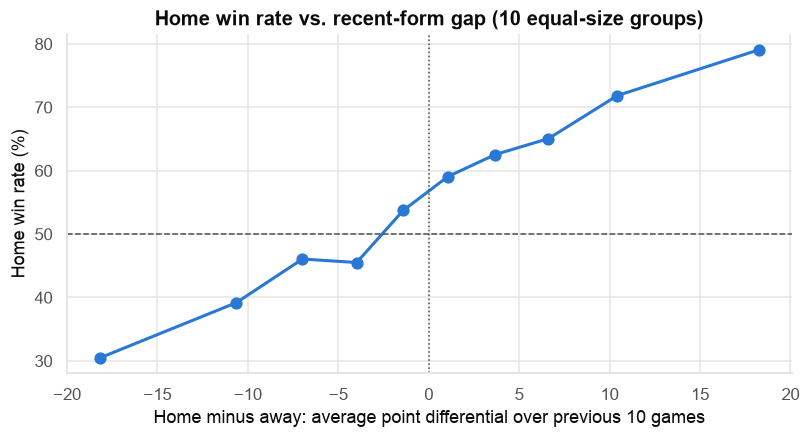

,gap,home_win,games
form_bucket,,,
"(-48.001, -13.12]",-18.179,0.305,712
"(-13.12, -8.54]",-10.634,0.392,712
"(-8.54, -5.417]",-6.980,0.461,712
"(-5.417, -2.7]",-3.985,0.455,725
"(-2.7, -0.2]",-1.414,0.537,711
"(-0.2, 2.3]",1.052,0.591,706
"(2.3, 5.1]",3.679,0.626,713
"(5.1, 8.2]",6.617,0.651,707
"(8.2, 13.0]",10.424,0.718,714


In [10]:
form = true_home.dropna(subset=["home_avg_point_diff_last10", "away_avg_point_diff_last10"]).copy()
form["form_gap"] = form["home_avg_point_diff_last10"] - form["away_avg_point_diff_last10"]
form["form_bucket"] = pd.qcut(form["form_gap"], 10)
by_bucket = form.groupby("form_bucket", observed=True).agg(
    gap=("form_gap", "mean"), home_win=("home_team_win", "mean"), games=("home_team_win", "size"))

fig, ax = plt.subplots(figsize=(8.5, 4))
ax.plot(by_bucket["gap"], by_bucket["home_win"] * 100, color=BLUE, linewidth=2, marker="o", markersize=7)
ax.axhline(50, color=MUTED, linestyle="--", linewidth=1)
ax.axvline(0, color=MUTED, linestyle=":", linewidth=1)
ax.set(title="Home win rate vs. recent-form gap (10 equal-size groups)",
       xlabel="Home minus away: average point differential over previous 10 games",
       ylabel="Home win rate (%)")
plt.show()
by_bucket.round(3)

**X-axis:** how much better the home team's recent point differential was than the away team's
(each dot is a group of about 700 games). **Y-axis:** how often the home team won in that group.

**What it shows:** a clear, steady upward relationship. When the home team has been playing much better
recently, it wins most of the time. When it has been playing much worse, it usually loses.
At a gap of 0, the home team still wins a bit more than half (home-court advantage again).

**Why it matters:** recent point differential carries real predictive information. It works better than recent
*win %*, because a 20-point win tells you more than a 1-point win. Correlation, not causation: the gap mostly
reflects which team is better overall, which Elo (section 7) measures more directly.

## 6. Rest and back-to-backs

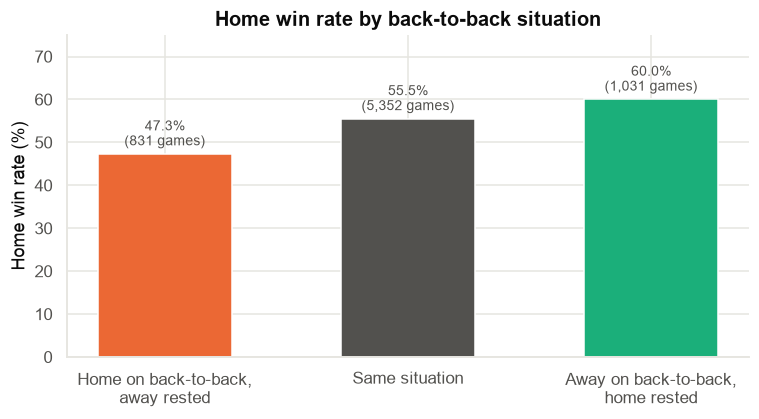

In [11]:
rest_gap = true_home["away_is_back_to_back"] - true_home["home_is_back_to_back"]
labels = {-1: "Home on back-to-back,\naway rested", 0: "Same situation", 1: "Away on back-to-back,\nhome rested"}
rest = true_home.groupby(rest_gap)["home_team_win"].agg(["mean", "size"]).rename(index=labels)

fig, ax = plt.subplots(figsize=(8, 3.8))
bars = ax.bar(rest.index, rest["mean"] * 100, color=[ORANGE, MUTED, AQUA], width=0.55)
ax.bar_label(bars, labels=[f"{m:.1%}\n({n:,} games)" for m, n in zip(rest["mean"], rest["size"])],
             padding=3, color=MUTED, fontsize=9)
ax.set(title="Home win rate by back-to-back situation", ylabel="Home win rate (%)")
ax.set_ylim(0, 75)
plt.show()

**X-axis:** which team, if either, played the night before. **Y-axis:** home team win rate.

**What it shows:** the home team wins **47%** when it's the tired team and **60%** when the opponent is.
That's a swing of about 13 percentage points, based on 800+ games per group.

**Why it matters:** rest comes from the **schedule**, which is published months ahead. It's known before
tip-off, so it's not leakage. Is fatigue the *cause*? Not necessarily: teams often sit star players on
back-to-backs, so part of the effect may be "who played" rather than tiredness. For *prediction*, the
feature is useful either way.

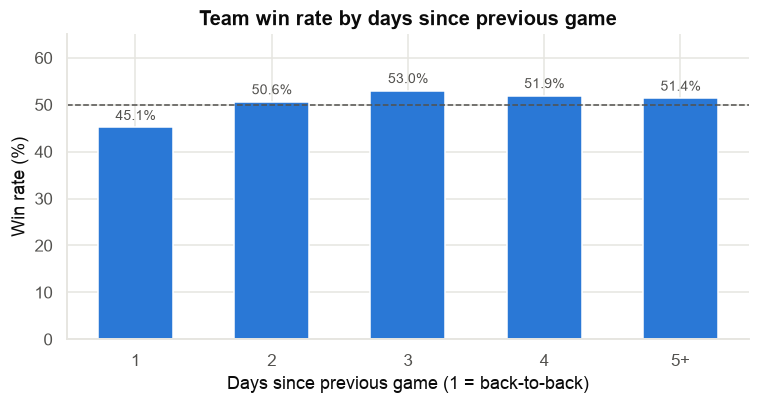

,win_rate,team_games
days,,
1,0.451,2594
2,0.506,9054
3,0.530,1977
4,0.519,335
5,0.514,288


In [12]:
rest_days = pd.concat([
    true_home[["home_days_since_last_game", "home_team_win"]].set_axis(["days", "won"], axis=1),
    true_home[["away_days_since_last_game", "home_team_win"]].set_axis(["days", "won"], axis=1)
        .assign(won=lambda d: 1 - d["won"]),
]).dropna()
rest_days["days"] = rest_days["days"].clip(upper=5).astype(int)
by_days = rest_days.groupby("days")["won"].agg(["mean", "size"])

fig, ax = plt.subplots(figsize=(8, 3.6))
bars = ax.bar(by_days.index.astype(str).str.replace("5", "5+"), by_days["mean"] * 100, color=BLUE, width=0.55)
ax.bar_label(bars, labels=[f"{m:.1%}" for m in by_days["mean"]], padding=3, color=MUTED, fontsize=9)
ax.axhline(50, color=MUTED, linestyle="--", linewidth=1)
ax.set(title="Team win rate by days since previous game", xlabel="Days since previous game (1 = back-to-back)",
       ylabel="Win rate (%)")
ax.set_ylim(0, 65)
plt.show()
by_days.rename(columns={"mean": "win_rate", "size": "team_games"}).round(3)

**X-axis:** days since the team's previous game (1 = back-to-back, 2 = one day off; 5+ includes the All-Star break).
**Y-axis:** how often a team in that situation won. Each game counts twice, once per team, so the average is 50%.

**What it shows:** teams on a back-to-back win noticeably less often (about 45%). Beyond one day off, extra rest
makes only a small difference (about 51-53%).

**Why it matters:** the useful information is mostly the back-to-back flag, not the exact number of rest days.

## 7. Elo ratings and calibration

Elo gives each team a rating that rises with wins and falls with losses, and **beating a strong team earns more
than beating a weak one**. Settings follow FiveThirtyEight's published NBA method (K = 20, +100 home advantage,
75% season carry-over). Ratings are warmed up on 2018-19 and 2019-20 so they're realistic by October 2020.

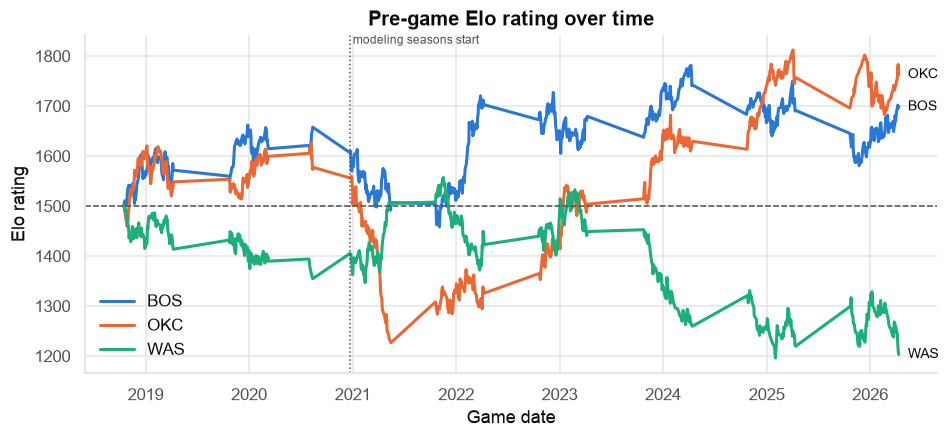

In [13]:
from src.feature_engineering import compute_elo

elo = all_games[["game_id", "game_date", "home_team", "away_team"]].merge(compute_elo(all_games), on="game_id")
history = pd.concat([
    elo[["game_date", "home_team", "home_elo"]].set_axis(["date", "team", "elo"], axis=1),
    elo[["game_date", "away_team", "away_elo"]].set_axis(["date", "team", "elo"], axis=1),
]).sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
for team, color in [("BOS", BLUE), ("OKC", ORANGE), ("WAS", AQUA)]:
    line = history[history["team"] == team]
    ax.plot(line["date"], line["elo"], color=color, linewidth=2, label=team)
    ax.annotate(team, (line["date"].iloc[-1], line["elo"].iloc[-1]), xytext=(6, 0),
                textcoords="offset points", color=INK, fontsize=9, va="center")
ax.axhline(1500, color=MUTED, linestyle="--", linewidth=1)
ax.axvline(pd.Timestamp("2020-12-22"), color=MUTED, linestyle=":", linewidth=1)
ax.text(pd.Timestamp("2020-12-22"), ax.get_ylim()[1], " modeling seasons start", color=MUTED, fontsize=8, va="top")
ax.set(title="Pre-game Elo rating over time", xlabel="Game date", ylabel="Elo rating")
ax.legend(frameon=False, loc="lower left")
plt.show()

**X-axis:** game date. **Y-axis:** a team's Elo rating before each game (1500 = average).

**What it shows:** ratings track real team quality. Oklahoma City falls during its rebuild (2021) and then rises to
the top of the league. Boston dips in 2020-21 and then stays near the top. Washington declines steadily. The flat gaps are offseasons. At each new season,
ratings are pulled 25% back toward average.

**Why it matters:** Elo adjusts for **opponent strength**, which the rolling averages don't. It's the strongest
single feature in section 8.

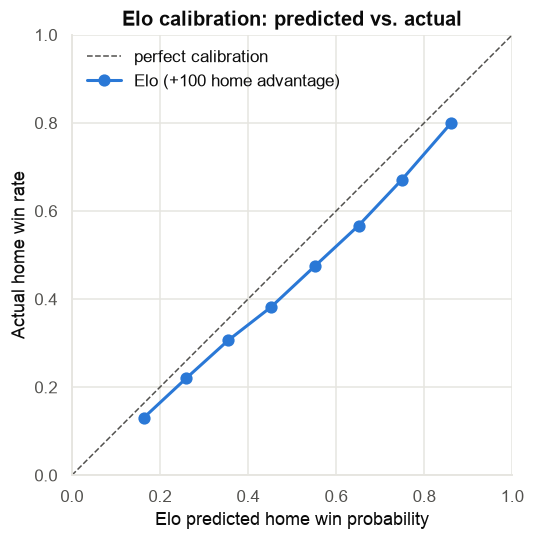

,predicted,actual,games
elo_home_win_prob,,,
"(0.0, 0.2]",0.163,0.130,92
"(0.2, 0.3]",0.260,0.220,309
"(0.3, 0.4]",0.355,0.307,584
"(0.4, 0.5]",0.452,0.382,822
"(0.5, 0.6]",0.552,0.475,1194
"(0.6, 0.7]",0.651,0.567,1515
"(0.7, 0.8]",0.749,0.671,1404
"(0.8, 1.0]",0.861,0.799,1310


In [14]:
bins = [0, .2, .3, .4, .5, .6, .7, .8, 1]
calibration = features.groupby(pd.cut(features["elo_home_win_prob"], bins), observed=True).agg(
    predicted=("elo_home_win_prob", "mean"), actual=("home_team_win", "mean"), games=("home_team_win", "size"))

fig, ax = plt.subplots(figsize=(5.5, 5.2))
ax.plot([0, 1], [0, 1], color=MUTED, linestyle="--", linewidth=1, label="perfect calibration")
ax.plot(calibration["predicted"], calibration["actual"], color=BLUE, linewidth=2, marker="o", markersize=7,
        label="Elo (+100 home advantage)")
ax.set(title="Elo calibration: predicted vs. actual", xlabel="Elo predicted home win probability",
       ylabel="Actual home win rate", xlim=(0, 1), ylim=(0, 1))
ax.set_aspect("equal")
ax.legend(frameon=False, loc="upper left")
plt.show()
calibration.round(3)

**X-axis:** Elo's predicted probability that the home team wins (games grouped into ranges).
**Y-axis:** how often the home team actually won in each group. A perfectly calibrated model sits on the dashed line.

**What it shows:** Elo **ranks** games well (its favorite wins about 64% of the time), but every point sits **below**
the line. It overstates the home team's chances by about 6–8 percentage points. The +100 home bonus implies
about 64% home wins between equal teams, which fits older NBA eras. In 2020–26, home teams win about 55%.

**Why it matters, and what we'll do:** this project compares model probabilities with **market prices**.
An uncalibrated model would show a fake "edge" on nearly every home team. We won't fix it by choosing a new
number from this chart, because that would tune on the test seasons. In Phase 2, calibration is fitted on the
**training seasons only** (tuned Elo settings and/or Platt scaling) and then evaluated on later seasons.

## 8. Feature signal summary

How well does each pre-game feature, alone, separate home wins from home losses? We use **AUC**: 0.5 is a coin flip
and 1.0 is perfect. Each feature is expressed as home-team advantage (home minus away, or the reverse for
"bad" stats). Non-neutral games only.

*This is a screening tool, not model selection. Final feature choices are made on training seasons only in Phase 2.*

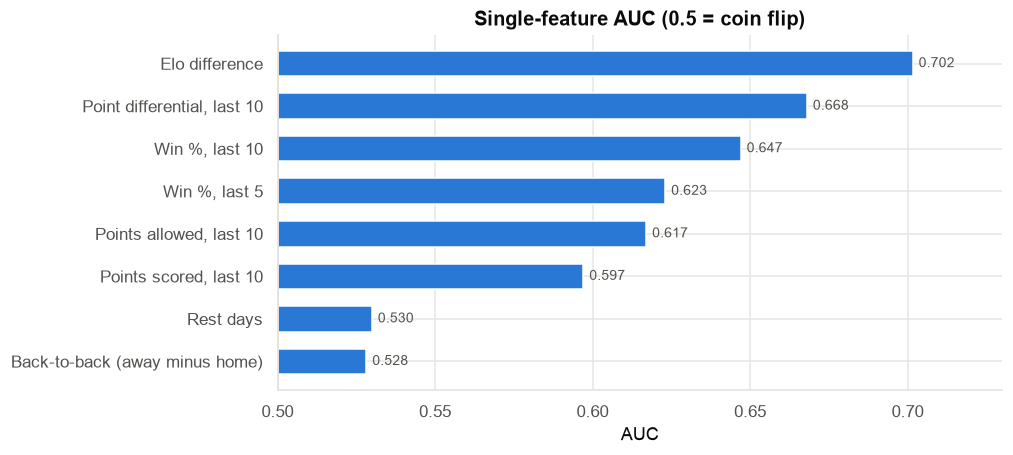

In [15]:
def auc(score: pd.Series, outcome: pd.Series) -> float:
    """Chance a random home win has a higher score than a random home loss (rank-based AUC)."""
    valid = score.notna()
    ranks, outcome = score[valid].rank(), outcome[valid]
    wins, losses = outcome.sum(), len(outcome) - outcome.sum()
    return (ranks[outcome == 1].sum() - wins * (wins + 1) / 2) / (wins * losses)

h, y = true_home, true_home["home_team_win"]
signals = {
    "Elo difference": h["elo_diff"],
    "Point differential, last 10": h["home_avg_point_diff_last10"] - h["away_avg_point_diff_last10"],
    "Win %, last 10": h["home_win_pct_last10"] - h["away_win_pct_last10"],
    "Win %, last 5": h["home_win_pct_last5"] - h["away_win_pct_last5"],
    "Points allowed, last 10": h["away_avg_pts_allowed_last10"] - h["home_avg_pts_allowed_last10"],
    "Points scored, last 10": h["home_avg_pts_scored_last10"] - h["away_avg_pts_scored_last10"],
    "Back-to-back (away minus home)": h["away_is_back_to_back"] - h["home_is_back_to_back"],
    "Rest days": h["home_days_since_last_game"] - h["away_days_since_last_game"],
}
signal_auc = pd.Series({name: auc(score, y) for name, score in signals.items()}).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 4.2))
bars = ax.barh(signal_auc.index, signal_auc.values - 0.5, left=0.5, color=BLUE, height=0.6)
ax.bar_label(bars, labels=[f"{v:.3f}" for v in signal_auc.values], padding=4, color=MUTED, fontsize=9)
ax.axvline(0.5, color=MUTED, linewidth=1)
ax.set(title="Single-feature AUC (0.5 = coin flip)", xlabel="AUC", xlim=(0.5, 0.73))
plt.show()

**X-axis:** AUC of each feature used alone. **Y-axis:** feature.

**What it shows:**
- **Elo is the strongest single feature**, followed by recent point differential. Both measure team strength.
- **Point differential beats win %.** Margins carry more information than wins and losses alone.
- **Rest features look weak alone** because back-to-backs affect only some games. But they measure
  something Elo cannot know (who played last night), so they add information on top of team strength.

**Why it matters:** these results point to three main pre-game factors: **team strength** (Elo / recent margin),
**home court**, and **fatigue**. Many other ideas tested during exploration (win streaks, head-to-head record,
strength of schedule, Four Factors) were mostly redundant once team strength was included.

## 9. Key findings and next steps

**Data**
- 7,230 games across six seasons, with no duplicates and exactly two teams and one winner per game.
- 16 neutral-site games identified (API format changed in 2024-25; earlier games documented by hand).
- The only missing values are season openers (no history) and one undefined 0/0 free-throw percentage.

**Patterns**
- Home teams win **about 55%**, stable across seasons, including 2020-21 with limited crowds.
- Margins are wide (standard deviation about 15 points), so outcomes are uncertain even for favorites.
- Recent point differential and Elo are strongly related to winning. Point differential beats win %.
- Back-to-backs shift home win rates from **47% to 60%** depending on which team is tired.

**Issues to handle in Phase 2**
- **Elo is miscalibrated** for the modern NBA (it overstates home teams). Calibrate on training seasons only.
- Use **chronological** train / validation / test splits. Never random splits.
- The main missing factor is **player availability** (injuries, rest days). Markets react to it, and this dataset doesn't contain it.

**Baselines a model must beat:** always pick home (55.2% accuracy), and the Elo favorite (64.3%).